# Dataset A – Adult Income



In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import StratifiedKFold, learning_curve, cross_validate
from sklearn.metrics import confusion_matrix


SEED=49
np.random.seed(SEED)
random.seed(SEED)

### Data Loading

We load the Adult Income dataset and inspect its basic structure.

In [3]:
DATA_PATH = "../adult.csv"
df = pd.read_csv(DATA_PATH)

df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
4,34.0,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,<=50K


If we look closely, `education` and `education-num` are redundant because they contain the same information, expressed in two different ways. For the purposes of creating the model, it would be best to omit one of them. We have decided to omit `education`, since `education-num` is a variable that is already numerical, which although it refers to categories, since there are many categories it will be better to treat it as numerical. 

The feature `fnlwgt` represents a census sampling weight rather than an individual-level attribute. Since our goal is predictive modeling at the individual level, this variable does not carry meaningful explanatory information and is excluded from the feature set.

## Experiments


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

X = df.drop(columns=["class", "fnlwgt", "education"])
y = df["class"]

num_cols = ["age", "hours-per-week", "capital-gain", "capital-loss", 'education-num']
cat_cols = ['workclass','marital-status','occupation','relationship','race','sex','native-country']

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)


70% training set, 20% testing set, 10% validation set

In [5]:
from sklearn.model_selection import train_test_split

y_bin = (pd.Series(y).astype(str).str.strip() == ">50K").astype(int).values

TEST_SIZE = 0.20
VAL_SIZE  = 0.10

X_train_t, X_test, y_train_t, y_test = train_test_split(
    X, y_bin, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

val_size_within_train = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_t, y_train_t, test_size=val_size_within_train, stratify=y_train_t, random_state=SEED
)

### Neural Network

#### PyTorch + SVD

In [6]:
import torch

X_train_sp = preprocessor.fit_transform(X_train)
X_val_sp   = preprocessor.transform(X_val)
X_test_sp  = preprocessor.transform(X_test)

X_train_nn = X_train_sp.toarray() if hasattr(X_train_sp, "toarray") else np.asarray(X_train_sp)
X_val_nn   = X_val_sp.toarray()   if hasattr(X_val_sp, "toarray")   else np.asarray(X_val_sp)
X_test_nn  = X_test_sp.toarray()  if hasattr(X_test_sp, "toarray")  else np.asarray(X_test_sp)

X_train_nn = X_train_nn.astype(np.float32, copy=False)
X_val_nn   = X_val_nn.astype(np.float32, copy=False)
X_test_nn  = X_test_nn.astype(np.float32, copy=False)

X_train_nn_t = torch.from_numpy(X_train_nn)
X_val_nn_t   = torch.from_numpy(X_val_nn)
X_test_nn_t  = torch.from_numpy(X_test_nn)

y_train_nn = torch.tensor(y_train, dtype=torch.long)
y_val_nn   = torch.tensor(y_val,   dtype=torch.long)
y_test_nn  = torch.tensor(y_test,  dtype=torch.long)

input_dim = X_train_nn_t.shape[1]

In [7]:
import torch
import torch.nn as nn

class MLP_tmp(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(d, h),
            nn.ReLU()
        )
        self.classifier = nn.Linear(h, 2)

    def forward(self, x):
        return self.classifier(self.features(x))

    def freeze_all(self):
        for p in self.parameters():
            p.requires_grad = False

    def unfreeze_last_k(self, k=1):
        self.freeze_all()
        for p in self.classifier.parameters():
            p.requires_grad = True
        if k >= 2:
            for m in self.features:
                if isinstance(m, nn.Linear):
                    for p in m.parameters():
                        p.requires_grad = True
    def count_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [44]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import time
from sklearn.metrics import accuracy_score, f1_score

import gc
gc.collect()

np.random.seed(SEED)
random.seed(SEED)

BATCH_SIZE = 64

train_ds = TensorDataset(X_train_nn_t, y_train_nn)
val_ds   = TensorDataset(X_val_nn_t,   y_val_nn)
test_ds  = TensorDataset(X_test_nn_t,  y_test_nn)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


device = "cuda" if torch.cuda.is_available() else "cpu"

model = MLP_tmp(d=input_dim, h=128).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def eval_f1(model, loader):
    """
    Compute F1 score for a PyTorch model

    Input:
        model (torch.nn.Module): trained neural network model
        loader (DataLoader): DataLoader providing evaluation batches

    Return:
        float: F1 score computed on the provided dataset
    """
    preds, ys = [], []

    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(next(model.parameters()).device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)

            preds.append(pred.cpu().numpy())
            ys.append(yb.cpu().numpy())

    return f1_score(np.concatenate(ys), np.concatenate(preds))


def eval_loss(model, loader):
    total, n = 0.0, 0
    model.eval()
    
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            bs = yb.size(0)
            total += loss.item() * bs
            n += bs
    return total / n


grad_evals = 0
t0 = time.time()

for epoch in range(10):  
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        grad_evals += 1
    vloss = eval_loss(model, val_loader)
    vf1   = eval_f1(model, val_loader)
    print(f"epoch {epoch:02d} | val_loss={vloss:.4f} | val_f1={vf1:.4f} | grad_evals={grad_evals} | time={time.time()-t0:.1f}s")



epoch 00 | val_loss=0.3197 | val_f1=0.6650 | grad_evals=495 | time=0.9s
epoch 01 | val_loss=0.3174 | val_f1=0.6869 | grad_evals=990 | time=1.6s
epoch 02 | val_loss=0.3157 | val_f1=0.6883 | grad_evals=1485 | time=2.3s
epoch 03 | val_loss=0.3182 | val_f1=0.6809 | grad_evals=1980 | time=3.1s
epoch 04 | val_loss=0.3179 | val_f1=0.7005 | grad_evals=2475 | time=3.8s
epoch 05 | val_loss=0.3182 | val_f1=0.6938 | grad_evals=2970 | time=4.6s
epoch 06 | val_loss=0.3218 | val_f1=0.7143 | grad_evals=3465 | time=5.3s
epoch 07 | val_loss=0.3174 | val_f1=0.6854 | grad_evals=3960 | time=6.0s
epoch 08 | val_loss=0.3164 | val_f1=0.6995 | grad_evals=4455 | time=6.7s
epoch 09 | val_loss=0.3189 | val_f1=0.6984 | grad_evals=4950 | time=7.5s


In [9]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

@torch.no_grad()
def evaluate_binary(model, loader, device="cpu"):
    model.eval()
    preds, ys = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.append(torch.argmax(logits, dim=1).cpu().numpy())
        ys.append(yb.cpu().numpy())
    y_pred = np.concatenate(preds)
    y_true = np.concatenate(ys)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "cm": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred
    }

In [10]:
res = evaluate_binary(model, test_loader, device=device)
print("Accuracy:", res["accuracy"])
print("F1:", res["f1"])
print("Confusion matrix:\n", res["cm"])

Accuracy: 0.8531785516860144
F1: 0.6850094876660341
Confusion matrix:
 [[6273  530]
 [ 798 1444]]


In [11]:
import copy
baseline_state = copy.deepcopy(model.state_dict())

## PART 1

### Hypothesis

Because the last layers of a trained backbone are closer to a near-convex classification head, we expect randomized optimization to sometimes find slightly better “tail” validation loss than local gradient updates restricted to the same layers. However, under strict function evaluation budgets, RO methods should be less sample-efficient and show higher variance across seeds. We expect:
- GA to be the most capable of escaping shallow local minima
- SA to depend strongly on its cooling schedule
- RHC to plateau early unless restarts are used

In [13]:
PARAM_CAP = 50_000

def prepare_last_k(model, k):
    model.load_state_dict(baseline_state)   
    model.unfreeze_last_k(k=k)              
    tp = model.count_trainable_params()
    return tp

for k in [1, 2]:
    tp = prepare_last_k(model, k)
    print(f"k={k} -> trainable params = {tp}")


chosen_k = None
for k in [2, 1]:
    tp = prepare_last_k(model, k)
    if tp <= PARAM_CAP:
        chosen_k = k
        trainable_params = tp
        break

print(f"Chosen k={chosen_k} with trainable params={trainable_params} (cap={PARAM_CAP})")

k=1 -> trainable params = 258
k=2 -> trainable params = 11522
Chosen k=2 with trainable params=11522 (cap=50000)


In [18]:
def get_trainable_tensors(model: nn.Module):
    return [p for p in model.parameters() if p.requires_grad]

def flatten_trainable(model: nn.Module) -> torch.Tensor:
    vec = torch.cat([p.detach().flatten() for p in get_trainable_tensors(model)], dim=0)
    return vec.to(device)

@torch.no_grad()
def assign_flattened_trainable(model: nn.Module, flat_vec: torch.Tensor):
    flat_vec = flat_vec.detach().to(device)
    idx = 0
    for p in get_trainable_tensors(model):
        n = p.numel()
        chunk = flat_vec[idx:idx+n].view_as(p)
        p.copy_(chunk)
        idx += n
    assert idx == flat_vec.numel()

    
class ROObjective:
    def __init__(self, model, val_loader):
        self.model = model
        self.val_loader = val_loader
        self.fevals = 0

    @torch.no_grad()
    def __call__(self, flat_vector):
        self.fevals += 1
        assign_flattened_trainable(self.model, flat_vector)
        return float(eval_loss(self.model, self.val_loader))

In [19]:
model.load_state_dict(baseline_state)
model.unfreeze_last_k(k=chosen_k)

x0 = flatten_trainable(model)
obj = ROObjective(model, val_loader)

y0 = obj(x0)
print("RO dim:", x0.numel())
print("Initial val loss:", y0, "| fevals:", obj.fevals)

RO dim: 11522
Initial val loss: 0.3163915362877048 | fevals: 1


### RHC

In [24]:
import math

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def rhc(obj, x_init, max_fevals=8000, restarts=10, sigma_init=0.02, sigma_decay=0.999, seed=49):
    set_all_seeds(seed)
    start = time.time()

    best_x = x_init.clone()
    best_y = obj(best_x)

    history = [(obj.fevals, best_y, time.time()-start)]

    per_restart = max(1, (max_fevals - obj.fevals) // restarts)

    for r in range(restarts):
        if obj.fevals >= max_fevals:
            break

        x = best_x + torch.randn_like(best_x) * (sigma_init * 2.0)
        y = obj(x)
        sigma = sigma_init

        local_best_x, local_best_y = x.clone(), y

        steps = 0
        while obj.fevals < max_fevals and steps < per_restart:
            x_prop = x + torch.randn_like(x) * sigma
            y_prop = obj(x_prop)

            if y_prop < y:
                x, y = x_prop, y_prop
                if y < local_best_y:
                    local_best_x, local_best_y = x.clone(), y

            sigma *= sigma_decay
            steps += 1

            if local_best_y < best_y:
                best_x, best_y = local_best_x.clone(), local_best_y

            history.append((obj.fevals, best_y, time.time()-start))

    hist = pd.DataFrame(history, columns=["fevals", "best_val_loss", "time_s"])
    return best_x, best_y, hist

### SA

In [33]:
def sa(obj, x_init, max_fevals = 8000, T0 = 1.0, alpha = 0.999, sigma_init = 0.02, sigma_decay = 0.9995, seed = 49):
    
    set_all_seeds(seed)
    start = time.time()

    x = x_init.clone()
    y = obj(x)

    best_x, best_y = x.clone(), y
    T = T0
    sigma = sigma_init

    history = [(obj.fevals, best_y, time.time() - start)]

    while obj.fevals < max_fevals:
        x_prop = x + torch.randn_like(x) * sigma
        y_prop = obj(x_prop)

        if y_prop < y:
            accept = True
        else:
            delta = y_prop - y
            accept_prob = math.exp(-delta / max(T, 1e-12))
            accept = (random.random() < accept_prob)

        if accept:
            x, y = x_prop, y_prop
            if y < best_y:
                best_x, best_y = x.clone(), y

        T *= alpha
        sigma *= sigma_decay

        history.append((obj.fevals, best_y, time.time() - start))

    hist = pd.DataFrame(history, columns=["fevals", "best_val_loss", "time_s"])
    return best_x, best_y, hist

### GA

In [30]:
import time, random
import numpy as np
import pandas as pd
import torch

def ga(obj, x_init, max_fevals = 8000, pop_size = 40, elite_frac = 0.10, tournament_k = 3, crossover_rate = 0.6, mutation_rate = 0.2, mutation_sigma = 0.02, seed = 49):
    set_all_seeds(seed)
    
    start = time.time()
    dim = x_init.numel()
    elite_n = max(1, int(pop_size * elite_frac))

    pop = [x_init + torch.randn_like(x_init) * mutation_sigma for _ in range(pop_size)]
    fits = [obj(ind) for ind in pop]

    best_idx = int(np.argmin(fits))
    best_x = pop[best_idx].clone()
    best_y = float(fits[best_idx])

    history = [(obj.fevals, best_y, time.time() - start)]

    while obj.fevals < max_fevals:

        order = np.argsort(fits)
        new_pop = [pop[i].clone() for i in order[:elite_n]]

        while len(new_pop) < pop_size and obj.fevals < max_fevals:

            idxs = np.random.choice(len(pop), size=tournament_k, replace=False)
            best_i = idxs[0]
            for i in idxs[1:]:
                if fits[i] < fits[best_i]:
                    best_i = i
            p1 = pop[best_i]

            idxs = np.random.choice(len(pop), size=tournament_k, replace=False)
            best_i = idxs[0]
            for i in idxs[1:]:
                if fits[i] < fits[best_i]:
                    best_i = i
            p2 = pop[best_i]

            if random.random() < crossover_rate:
                mask = torch.rand(dim, device=x_init.device) < 0.5
                c1 = torch.where(mask, p1, p2)
                c2 = torch.where(mask, p2, p1)
            else:
                c1 = p1.clone()
                c2 = p2.clone()

            if random.random() < mutation_rate:
                c1 = c1 + torch.randn_like(c1) * mutation_sigma
            if random.random() < mutation_rate:
                c2 = c2 + torch.randn_like(c2) * mutation_sigma

            new_pop.append(c1)
            if len(new_pop) < pop_size:
                new_pop.append(c2)

        pop = new_pop[:pop_size]
        fits = [obj(ind) for ind in pop]

        gen_best_idx = int(np.argmin(fits))
        gen_best_y = float(fits[gen_best_idx])

        if gen_best_y < best_y:
            best_y = gen_best_y
            best_x = pop[gen_best_idx].clone()

        history.append((obj.fevals, best_y, time.time() - start))

    hist = pd.DataFrame(history, columns=["fevals", "best_val_loss", "time_s"])
    return best_x, best_y, hist

### Design Disclosures

Backbone: MLP_tmp  
Trainable layers: last k=2  
Trainable parameters: 11522  
Objective: validation CrossEntropyLoss  
Budget: 1000 function evaluations  

#### RHC
- Restarts: 10  
- Sigma_init: 0.02  
- Sigma_decay: 0.999  

#### SA
- T0: 1.0  
- Alpha: 0.999  
- Sigma_init: 0.02  
- Sigma_decay: 0.9995  

#### GA
- Population size: 40  
- Tournament_k: 3  
- Crossover rate: 0.6  
- Mutation rate: 0.2  
- Mutation sigma: 0.02  
- Elitism: 10%

In [37]:
SEEDS = [49,35,11]
BUDGET_FEVALS = 1000

def run_ro_method(method_name, method_fn, seed, **kwargs):
    model.load_state_dict(baseline_state)
    model.unfreeze_last_k(k=chosen_k)
    x0 = flatten_trainable(model)
    obj = ROObjective(model, val_loader)

    best_x, best_val, hist = method_fn(obj, x0, max_fevals=BUDGET_FEVALS, seed=seed, **kwargs)
    return {
        "method": method_name,
        "seed": seed,
        "best_val_loss": float(best_val),
        "final_fevals": int(obj.fevals),
        "final_time_s": float(hist["time_s"].iloc[-1]),
        "hist": hist,
        "best_x": best_x.detach().clone()
    }

runs = []

# RHC settings 
for s in SEEDS:
    runs.append(run_ro_method("RHC", rhc, s, restarts=10, sigma_init=0.02, sigma_decay=0.999))
    
# SA settings
for s in SEEDS:
    runs.append(run_ro_method("SA", sa, s, T0=1.0, alpha=0.999, sigma_init=0.02, sigma_decay=0.9995))

# GA settings
for s in SEEDS:
    runs.append(run_ro_method("GA", ga, s, pop_size=40, elite_frac=0.10, tournament_k=3,
                              crossover_rate=0.6, mutation_rate=0.2, mutation_sigma=0.02))

print("Total runs:", len(runs))

Total runs: 9


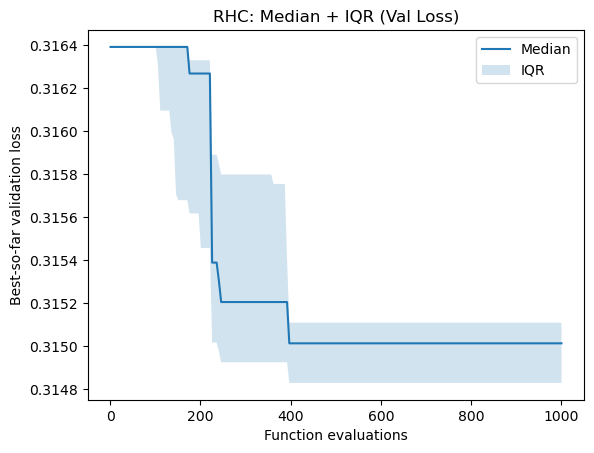

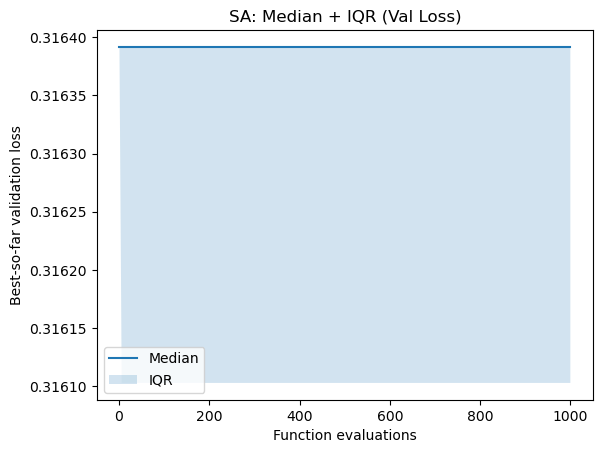

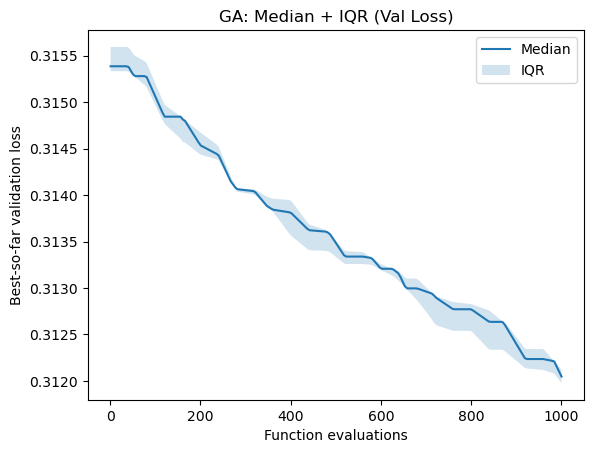

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_median_iqr(runs, method, budget):
    method_runs = [r for r in runs if r["method"] == method]
    
    grid = np.linspace(1, budget, 200).astype(int)
    
    Ys = []
    for r in method_runs:
        h = r["hist"].drop_duplicates("fevals").sort_values("fevals")
        y_interp = np.interp(grid, h["fevals"].values, h["best_val_loss"].values)
        Ys.append(y_interp)
    
    Ys = np.vstack(Ys)
    
    median = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, median, label="Median")
    plt.fill_between(grid, q1, q3, alpha=0.2, label="IQR")
    plt.xlabel("Function evaluations")
    plt.ylabel("Best-so-far validation loss")
    plt.title(f"{method}: Median + IQR (Val Loss)")
    plt.legend()
    plt.show()


for m in ["RHC", "SA", "GA"]:
    plot_median_iqr(runs, m, BUDGET_FEVALS)

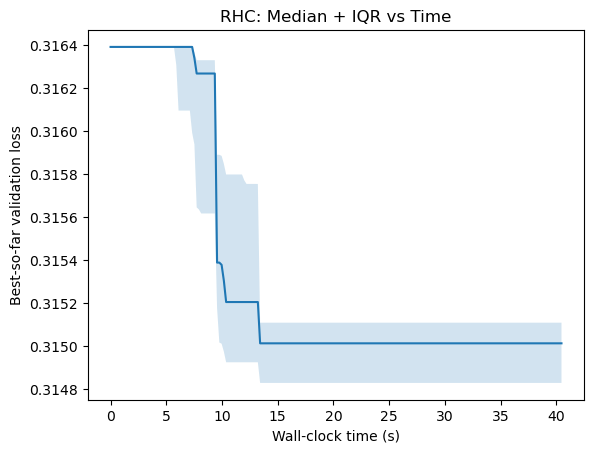

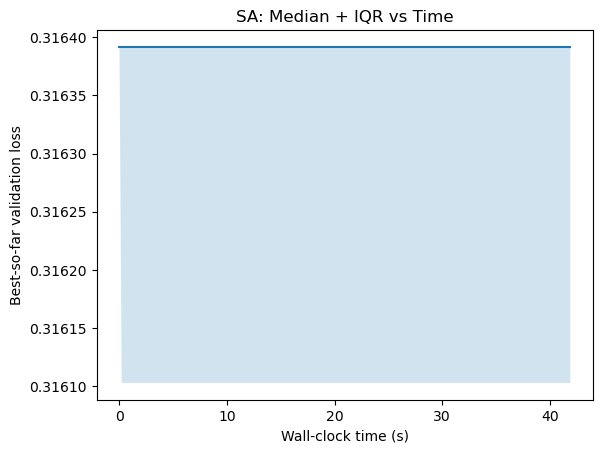

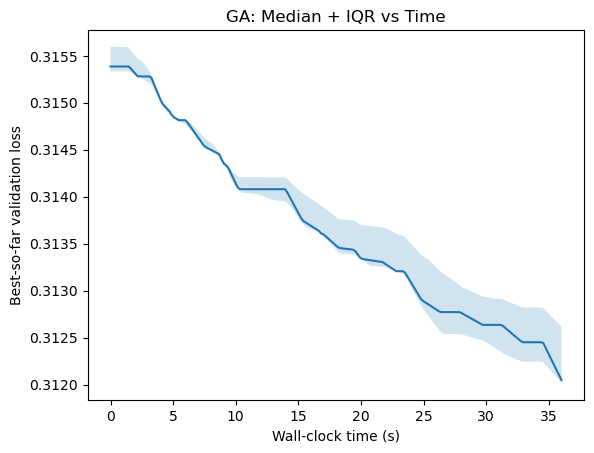

In [42]:
def plot_median_iqr_time(runs, method):
    method_runs = [r for r in runs if r["method"] == method]
    
    max_time = min(r["hist"]["time_s"].max() for r in method_runs)
    grid = np.linspace(0, max_time, 200)
    
    Ys = []
    for r in method_runs:
        h = r["hist"].drop_duplicates("time_s").sort_values("time_s")
        y_interp = np.interp(grid, h["time_s"].values, h["best_val_loss"].values)
        Ys.append(y_interp)
    
    Ys = np.vstack(Ys)
    
    median = np.median(Ys, axis=0)
    q1 = np.quantile(Ys, 0.25, axis=0)
    q3 = np.quantile(Ys, 0.75, axis=0)

    plt.figure()
    plt.plot(grid, median)
    plt.fill_between(grid, q1, q3, alpha=0.2)
    plt.xlabel("Wall-clock time (s)")
    plt.ylabel("Best-so-far validation loss")
    plt.title(f"{method}: Median + IQR vs Time")
    plt.show()


for m in ["RHC", "SA", "GA"]:
    plot_median_iqr_time(runs, m)

In [45]:
model.load_state_dict(baseline_state)
baseline_f1 = eval_f1(model, test_loader)
print("Baseline Test F1:", baseline_f1)

final_results = []

for method in ["RHC", "SA", "GA"]:
    method_runs = [r for r in runs if r["method"] == method]
    
    best_run = min(method_runs, key=lambda x: x["best_val_loss"])
    
    model.load_state_dict(baseline_state)
    model.unfreeze_last_k(k=chosen_k)
    assign_flattened_trainable(model, best_run["best_x"])
    
    test_f1 = eval_f1(model, test_loader)
    
    final_results.append({
        "method": method,
        "best_val_loss": best_run["best_val_loss"],
        "test_f1": test_f1,
        "seed": best_run["seed"]
    })

df = pd.DataFrame(final_results)
df

Baseline Test F1: 0.6850094876660341


,method,best_val_loss,test_f1,seed
0,RHC,0.314643,0.668481,11
1,SA,0.315814,0.669777,11
2,GA,0.311909,0.667814,35


## PART 2

## PART 3